# 双窗口 FI —— 图与交付物

接在 `window_fi_contrast.ipynb` 之后。**自给自足**:重新载数据和 `fi_per_seed.npz`,
不依赖上一个 notebook 的 kernel 状态。

## 交付什么(guide §7)

| 产物 | guide | 本 notebook |
|---|---|---|
| Fig 1 方法一致性热图 | §3 | Part 4 |
| Fig 2 跨窗口 FI 散点 | §4 | Part 5 |
| Fig 3 沿序列 profile + 水面板 | §4 | Part 6 |
| Fig 4 PyMOL 双图 | §5 | Part 7 |
| 一句话解读 | §7 | Part 8(带真实数字自动生成) |

## 顺序

| Part | 内容 | 必须? |
|---|---|---|
| 0 | 配置 + 重新载入 | 必须 |
| 1 | SHAP 回填 | 装了 shap 才跑;guide §2 要三种方法 |
| 2 | 残基编号诊断 → 决定 Fig 3 的 x 轴 | 必须 |
| 3 | 按地板选主方法(§3 要求"说明选哪个、为什么") | 必须 |
| 4–7 | 四张图 | 必须 |
| 8 | 解读文本 | 必须 |

## 已知的前提

正式跑的结果:TS 的 permutation 地板 top-15 Jaccard = 0.200(弱但真实),
**late 只有 0.034 —— 不可复现**。所以 Part 3 会按地板自动选方法,而不是
机械照抄 guide §8 的"lead with permutation"。这正好满足 §3 那句
"State which and why"。

In [1]:
import json, os, time, warnings
from itertools import combinations

import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold

# ===== 必须和 window_fi_contrast.ipynb 那次正式跑完全一致 =====
H5_PATH     = "/mnt/data1/student/trypsin/h5_datasets/CV_database_4864_TS_variedDCDfreq_lmin2p6_lmax4p0.h5"
PDB_PATH    = "/mnt/data1/student/trypsin/h5_datasets/step3_input.pdb"
WATERS_PATH = "/mnt/data1/student/trypsin/h5_datasets/4864_TS_50closest_waters.npy"
OUT_DIR     = "/mnt/data1/student/trypsin/yucheng/07.12/v4"
FIG_DIR     = os.path.join(OUT_DIR, "figures")

WINDOWS   = {"TS": (500, 1501), "late": (2000, 2500)}
RF_PARAMS = dict(n_estimators=300, max_features="sqrt", min_samples_leaf=2,
                 class_weight="balanced_subsample", n_jobs=-1)
N_SPLITS, SEEDS, TOP_K = 5, list(range(10)), 15
N_PROTEIN, N_WATERS = 224, 50
MIN_RELIABILITY = 0.20

# guide §6:轴标签/刻度 >= 16-18pt
mpl.rcParams.update({
    "font.size": 16, "axes.labelsize": 18, "axes.titlesize": 18,
    "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 14,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})
# 色盲安全:Okabe-Ito
C_PROT, C_WATER = "#0072B2", "#E69F00"      # 蛋白 蓝 / 水 橙
C_FAR,  C_NEAR  = "#D55E00", "#56B4E9"      # OUT 时更远 红 / 更近 蓝
os.makedirs(FIG_DIR, exist_ok=True)

try:
    import shap; HAVE_SHAP = True; print("shap", shap.__version__)
except ImportError:
    HAVE_SHAP = False; print("shap 不可用 —— Part 1 会跳过,只能出 2x2 的 Fig 1")
import mdtraj as md
print("mdtraj", getattr(md, "__version__", "?"), "| 图输出到", FIG_DIR)

shap 0.49.1
mdtraj 1.10.3 | 图输出到 /mnt/data1/student/trypsin/yucheng/07.12/v4/figures


/home/student/miniforge3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 0 — 重新载入

从 h5 重建两个窗口的特征矩阵,从 `fi_per_seed.npz` 读回上次算好的重要性。
不重训任何模型(除非 Part 1 要补 SHAP)。

In [2]:
t0 = time.time()
with h5py.File(H5_PATH, "r") as h:
    cv_data = h["cv_data"][:]; labels_raw = h["labels"][:]; groups = h["replica_ids"][:]
labels = np.array([v.decode(errors="replace") if isinstance(v, (bytes, np.bytes_)) else str(v)
                   for v in labels_raw])
y = np.array([0 if l == "IN" else 1 for l in labels], dtype=np.int64)   # IN=0, OUT=1

Xs = {k: cv_data[:, a:b, :].mean(axis=1).astype(np.float64) for k, (a, b) in WINDOWS.items()}
del cv_data

# 特征名(guide §1)。水按 rank 命名 —— "第 i 近的水"每帧是不同分子。
topo = md.load(PDB_PATH).topology
residues = [r for r in topo.residues if r.is_protein]
assert len(residues) == N_PROTEIN, f"蛋白残基 {len(residues)} != {N_PROTEIN}"
waters = np.load(WATERS_PATH, allow_pickle=True)
names = {
    "name":  np.concatenate([[f"{r.name}{r.resSeq}" for r in residues],
                             [f"water rank{i}" for i in range(N_WATERS)]]),
    "kind":  np.array(["protein"] * N_PROTEIN + ["water"] * N_WATERS),
    "resid": np.concatenate([[r.resSeq for r in residues], np.full(N_WATERS, -1)]).astype(int),
    "chain": np.concatenate([[r.chain.index for r in residues], np.full(N_WATERS, -1)]).astype(int),
}
IS_PROT = names["kind"] == "protein"
IS_WAT  = ~IS_PROT

z = dict(np.load(os.path.join(OUT_DIR, "fi_per_seed.npz"), allow_pickle=True))
per_seed = {w: {m: z[f"{w}__{m}"] for m in ("gini", "perm", "shap") if f"{w}__{m}" in z}
            for w in WINDOWS}
oof = {w: z[f"{w}__oof"].tolist() for w in WINDOWS}

def grouped_splits(y, groups, n_splits, seed):
    sp = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return [(tr, te) for tr, te in sp.split(np.arange(len(y)), y, groups)]

for w in WINDOWS:
    print(f"  {w:6s} X={Xs[w].shape}  方法={sorted(per_seed[w])}  OOF={np.mean(oof[w]):.3f}")
print(f"载入完成 {time.time()-t0:.0f}s")

  TS     X=(173, 274)  方法=['gini', 'perm', 'shap']  OOF=0.664
  late   X=(173, 274)  方法=['gini', 'perm', 'shap']  OOF=0.761
载入完成 2s


## Part 1 — SHAP 回填

guide §2 要三种方法。这一格**不重跑 permutation**——整条流水线是确定性的
(`split` 只吃 seed,`random_state = 10_000*seed + fold`),重新拟合出的森林
逐棵树相同,所以补算的 SHAP 和"当初就开着跑"完全一致。

贵的是 permutation(274 特征 × 10 repeats × 5 折);SHAP 在 35 行测试集上几乎免费。
约 10–15 分钟。

没装 shap 就跳过,后面照常跑,只是 Fig 1 变成 2×2。

In [3]:
def shap_missing(w):
    """全 NaN 占位不算数 —— 主 notebook 在 RUN_SHAP=False 时会存 np.full(274, nan)。"""
    return "shap" not in per_seed[w] or not np.isfinite(per_seed[w]["shap"]).any()

need_shap = HAVE_SHAP and any(shap_missing(w) for w in WINDOWS)

if not need_shap:
    print("跳过:" + ("shap 未安装" if not HAVE_SHAP else "SHAP 已在 npz 里(且是有效数值)"))
else:
    t0 = time.time()
    for wkey in WINDOWS:
        if not shap_missing(wkey):          # ← 这里也要用同一个判断
            print(f"  {wkey}: 已有有效 SHAP,跳过")
            continue
        rows = []
        for seed in SEEDS:
            acc, n_ok = np.zeros(Xs[wkey].shape[1]), 0
            for fold, (tr, te) in enumerate(grouped_splits(y, groups, N_SPLITS, seed)):
                rf = RandomForestClassifier(random_state=10_000 * seed + fold, **RF_PARAMS)
                rf.fit(Xs[wkey][tr], y[tr])
                sv = shap.TreeExplainer(rf).shap_values(Xs[wkey][te])
                if isinstance(sv, list):                            # shap < 0.45
                    arr = sv[1] if len(sv) > 1 else sv[0]
                elif isinstance(sv, np.ndarray) and sv.ndim == 3:   # >= 0.45,你是 0.49
                    arr = sv[:, :, 1] if sv.shape[2] > 1 else sv[:, :, 0]
                else:
                    arr = sv
                acc += np.abs(arr).mean(axis=0); n_ok += 1
            rows.append(acc / n_ok)
            print(f"  {wkey:6s} seed={seed:<2d} ({time.time()-t0:.0f}s)")
        M = np.vstack(rows)
        assert np.isfinite(M).any() and M.std() > 0, f"{wkey} 算出来的 SHAP 无效"
        per_seed[wkey]["shap"] = M
        z[f"{wkey}__shap"] = M
    np.savez(os.path.join(OUT_DIR, "fi_per_seed.npz"), **z)
    print(f"SHAP 已并入 npz,用时 {time.time()-t0:.0f}s")

fi_mean = {w: {m: per_seed[w][m].mean(axis=0) for m in per_seed[w]} for w in WINDOWS}

def method_is_valid(m):
    for w in WINDOWS:
        if m not in per_seed[w]:
            return False, f"{w} 缺这个方法"
        M = per_seed[w][m]
        if not np.isfinite(M).any():
            return False, f"{w} 全是 NaN(占位数组,不是真结果)"
        if np.nanstd(M) == 0:
            return False, f"{w} 是常数"
    return True, ""

METHODS = []
for m in ("gini", "perm", "shap"):
    ok, why = method_is_valid(m)
    if ok:
        METHODS.append(m)
    elif m in per_seed[list(WINDOWS)[0]]:
        print(f"  丢弃 {m}:{why}")
assert METHODS, "没有任何有效方法 —— 检查 npz"
print("可用方法:", METHODS)

跳过:SHAP 已在 npz 里(且是有效数值)
可用方法: ['gini', 'perm', 'shap']


## Part 2 — 残基编号诊断 → 决定 Fig 3 的 x 轴

主 notebook 报了 `残基号范围 1–241`,但第一个残基是 `ILE19`。**Fig 3 的 x 轴就是
残基号**,如果有重复、乱序或多链,整张图会错位。

这一格先诊断,再据此决定 x 轴:干净就用 resSeq,有问题就退回拓扑 index
(仍然按 resSeq 标注),两种情况都能出图。

In [4]:
rs = names["resid"][IS_PROT]
ch = names["chain"][IS_PROT]
nonmono = [i for i in range(1, len(rs)) if rs[i] <= rs[i - 1]]
dup     = sorted({int(x) for x in rs if (rs == x).sum() > 1})
chains  = sorted(set(ch.tolist()))

print(f"蛋白残基 {len(rs)} 个,resSeq {rs.min()}–{rs.max()},链 {chains}")
print(f"非递增处 {len(nonmono)} 个,重复号 {len(dup)} 个")
for i in nonmono[:6]:
    print(f"   idx {i-1:3d} {names['name'][i-1]:>8s}(chain {ch[i-1]})"
          f"  ->  idx {i:3d} {names['name'][i]:>8s}(chain {ch[i]})")
for c in chains:
    sub = rs[ch == c]
    print(f"   chain {c}: {len(sub)} 残基, resSeq {sub.min()}–{sub.max()}")

# mdtraj 的 is_protein 会把钙离子之类的辅因子也算进来(这里 chain 1 = CAL1)。
# 它们没有序列位置,不能进 Fig 3 的序列面板。但注意:数据 owner 的
# rescue_feature_names.ipynb 用的是同一个 is_protein 过滤,所以 CV 编号映射
# 是一致的 —— 只是画图时要把它们摘出去。
main_chain = max(chains, key=lambda c: (ch == c).sum())
seq_local  = np.where(ch == main_chain)[0]              # 主链在 224 个里的位置
extra_local = np.where(ch != main_chain)[0]

IS_SEQ = np.zeros(len(names["name"]), dtype=bool)
IS_SEQ[np.where(IS_PROT)[0][seq_local]] = True          # 全 274 维里的主链掩码
EXTRA_IDX = np.where(IS_PROT)[0][extra_local]           # CAL1 等

seq_rs = rs[seq_local]
CLEAN_RESID = bool(np.all(np.diff(seq_rs) > 0))
if CLEAN_RESID:
    XAXIS, XLABEL = seq_rs, "Residue number"
    print(f"\n>>> 主链 (chain {main_chain}) 的 resSeq {seq_rs.min()}–{seq_rs.max()} 单调干净")
    print(f"    Fig 3 用残基号作 x 轴,共 {len(seq_rs)} 个残基")
else:
    XAXIS, XLABEL = np.arange(len(seq_local)), "Residue index (topology order)"
    print("\n>>> 主链 resSeq 仍有异常 —— 退回拓扑 index")
if len(EXTRA_IDX):
    print(f"    摘出 {len(EXTRA_IDX)} 个非序列特征(不进序列面板,重要性在文本里单独报):")
    for i in EXTRA_IDX:
        print(f"      CV_{i} = {names['name'][i]}  (chain {names['chain'][i]})")

蛋白残基 224 个,resSeq 1–241,链 [0, 1]
非递增处 1 个,重复号 0 个
   idx 222   ASN241(chain 0)  ->  idx 223     CAL1(chain 1)
   chain 0: 223 残基, resSeq 19–241
   chain 1: 1 残基, resSeq 1–1

>>> 主链 (chain 0) 的 resSeq 19–241 单调干净
    Fig 3 用残基号作 x 轴,共 223 个残基
    摘出 1 个非序列特征(不进序列面板,重要性在文本里单独报):
      CV_223 = CAL1  (chain 1)


## Part 3 — 选一个方法贯穿所有图

guide §3 要求:*"Pick one method to carry the rest of the figures — permutation or SHAP.
State which and why."*

guide §8 的默认建议是 permutation。但**你的数据不支持机械照抄**:正式跑的结果
显示 late 窗口 permutation 的 split-half 地板只有 Jaccard 0.034 —— 连自己都复现不了。

所以这里按**实测地板**选,并打印出理由。这比照抄更有说服力,而且正是 §3 要的
"state which and why"。

地板的定义:把 10 个 seed 对半分(5v5),每半平均,同一窗口两半之间的 top-15 Jaccard。
它衡量"同样的数据、只换随机种子,重要性排名有多稳"。

In [5]:
def topk_jaccard(a, b, k=TOP_K):
    ta, tb = set(np.argsort(a)[::-1][:k]), set(np.argsort(b)[::-1][:k])
    return len(ta & tb) / len(ta | tb)

PARTS = [set(c) for c in combinations(range(len(SEEDS)), len(SEEDS) // 2)]
PARTS = PARTS[:len(PARTS) // 2]          # (A,B) 与 (B,A) 等价

def split_half(M, k=TOP_K):
    """返回 (rho中位数, Jaccard中位数)。"""
    rr, jj = [], []
    for A in PARTS:
        B = [i for i in range(len(M)) if i not in A]
        a, b = M[sorted(A)].mean(axis=0), M[B].mean(axis=0)
        rr.append(spearmanr(a, b).statistic); jj.append(topk_jaccard(a, b, k))
    return float(np.median(rr)), float(np.median(jj))

floor = {}
print(f"{'方法':<8}{'窗口':<8}{'地板 rho':>10}{'地板 Jaccard':>14}")
for m in METHODS:
    for w in WINDOWS:
        floor[(m, w)] = split_half(per_seed[w][m])
        r, j = floor[(m, w)]
        flag = "  <- 不可复现" if j < 0.10 else ""
        print(f"{m:<8}{w:<8}{r:>10.3f}{j:>14.3f}{flag}")

# 主方法 = 在两个窗口里"最弱那一侧"最强的方法(木桶原理:跨窗口对比取决于弱侧)
cand = [m for m in METHODS if m != "gini"] or METHODS     # guide §8:不能只报 Gini
score = {m: min(floor[(m, w)][1] for w in WINDOWS) for m in cand}
PRIMARY = max(score, key=score.get)
print(f"\n各方法的最弱窗口地板: " + ", ".join(f"{m}={score[m]:.3f}" for m in cand))
print(f">>> 主方法 = {PRIMARY.upper()}")

RATIONALE = (
    f"Primary method: {PRIMARY}. Chosen on measured reproducibility rather than by default: "
    + "; ".join(f"{m} floor (split-half top-{TOP_K} Jaccard) = "
                + "/".join(f"{floor[(m,w)][1]:.3f} ({w})" for w in WINDOWS) for m in cand)
    + f". Gini is reported in Fig 1 for completeness but never used to draw conclusions, "
      f"because for tree models Gini and TreeExplainer-SHAP derive from the same splits "
      f"and are not independent checks of one another (guide §8)."
)
WEAK = [w for w in WINDOWS if floor[(PRIMARY, w)][1] < 0.10]
if WEAK:
    print(f"!! 警告:{WEAK} 窗口即使用 {PRIMARY} 地板仍 < 0.10 —— "
          f"该窗口的 top 特征不能当结论报,图里会标注。")

方法      窗口          地板 rho    地板 Jaccard
gini    TS           0.976         0.765
gini    late         0.977         0.875
perm    TS           0.116         0.200
perm    late         0.128         0.034  <- 不可复现
shap    TS           0.964         0.875
shap    late         0.977         1.000

各方法的最弱窗口地板: perm=0.034, shap=0.875
>>> 主方法 = SHAP


## Part 4 — Fig 1:方法一致性热图(guide §3)

每个窗口一个 3×3 Spearman 矩阵,标注数字,发散色标以 0 为中心,下方给 top-15 Jaccard。

**要在 slide 上说的话**(guide §3):"三种方法在 ρ ≈ 0.x 上一致,下面这些特征是三种
方法都选出来的,所以不是某个指标的 artefact。"

对照 guide §8 她的 demo:Gini↔SHAP 0.95/0.96、Gini↔Perm 0.02/0.29、Perm↔SHAP 0.02/0.31。
**Gini 和 SHAP 同源、permutation 才是独立那根轴** —— 别把 SHAP 当成对 Gini 的验证。

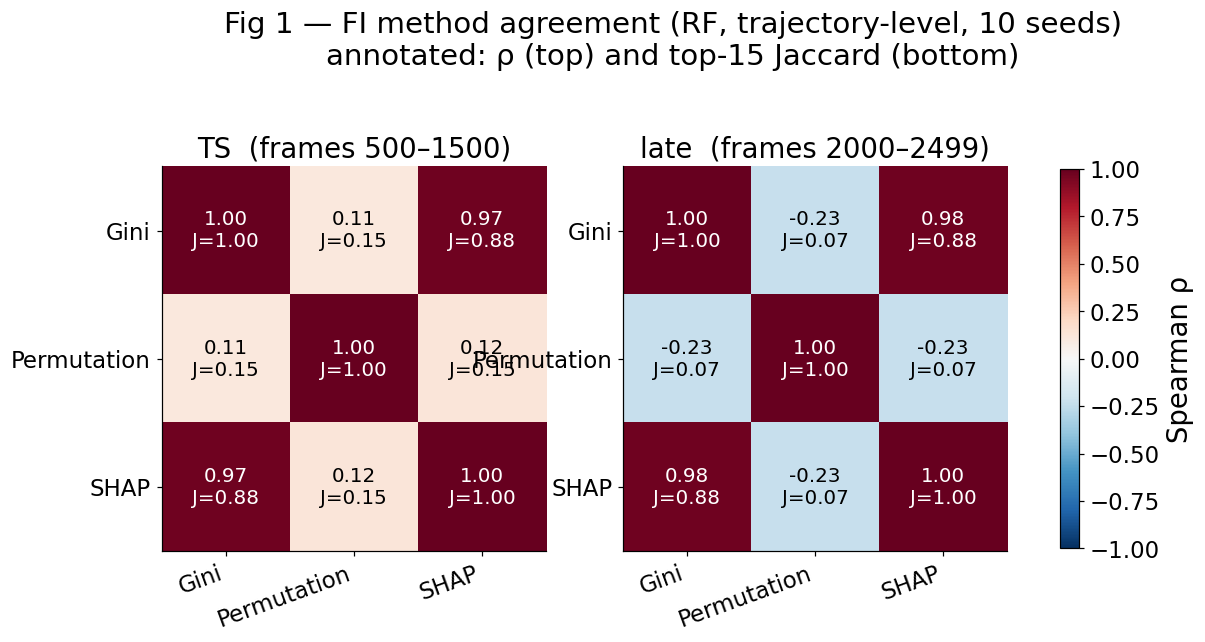

-> /mnt/data1/student/trypsin/yucheng/07.12/v4/figures/fig1_method_agreement.png

CAPTION: Spearman rank correlation between three feature-importance methods, per window. Model: RandomForest (300 trees), trajectory-level window means, 5-fold grouped CV averaged over 10 seeds; permutation and SHAP computed on held-out rows. Water CVs are rank-based (the i-th closest water is a different molecule in each frame) and are included in the 274 features.


In [6]:
LBL = {"gini": "Gini", "perm": "Permutation", "shap": "SHAP"}
nM = len(METHODS)
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(6.2 * len(WINDOWS), 5.6))
axes = np.atleast_1d(axes)

for ax, w in zip(axes, WINDOWS):
    R = np.array([[spearmanr(fi_mean[w][a], fi_mean[w][b]).statistic for b in METHODS]
                  for a in METHODS])
    J = np.array([[topk_jaccard(fi_mean[w][a], fi_mean[w][b]) for b in METHODS]
                  for a in METHODS])
    im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(nM):
        for j in range(nM):
            ax.text(j, i, f"{R[i,j]:.2f}\nJ={J[i,j]:.2f}", ha="center", va="center",
                    fontsize=13, color="white" if abs(R[i, j]) > 0.55 else "black")
    ax.set_xticks(range(nM), [LBL[m] for m in METHODS], rotation=20, ha="right")
    ax.set_yticks(range(nM), [LBL[m] for m in METHODS])
    a, b = WINDOWS[w]
    ax.set_title(f"{w}  (frames {a}–{b-1})")
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label="Spearman ρ")
fig.suptitle(f"Fig 1 — FI method agreement (RF, trajectory-level, {len(SEEDS)} seeds)\n"
             f"annotated: ρ (top) and top-{TOP_K} Jaccard (bottom)", y=1.06)
p = os.path.join(FIG_DIR, "fig1_method_agreement.png"); fig.savefig(p); plt.show()
print("->", p)
print("\nCAPTION: Spearman rank correlation between three feature-importance methods, "
      f"per window. Model: RandomForest ({RF_PARAMS['n_estimators']} trees), trajectory-level "
      f"window means, {N_SPLITS}-fold grouped CV averaged over {len(SEEDS)} seeds; permutation "
      "and SHAP computed on held-out rows. Water CVs are rank-based (the i-th closest water is "
      "a different molecule in each frame) and are included in the 274 features.")

## Part 5 — Fig 2:跨窗口 FI 散点(主图,guide §4)

- x = TS 窗口重要性,y = late 窗口重要性,同一方法
- 画 y = x 对角线:在线上 = 两个 regime 都重要;偏离 = regime 特异
- 标注 top-10 的名字,蛋白/水分色
- 标题给 `spearmanr(FI_TS, FI_late)`

**两个必要的处理:**

1. **各自归一化到最大值**。TS 和 late 的重要性绝对量级差一个数量级(窗口长度不同:
   1001 帧 vs 500 帧,平均掉的噪声量不同),不归一化的话 y=x 对角线没有意义。
2. **标题同时给地板**。guide §8 的 ρ≈0.05 单独看无法解释——274 个特征里大部分在两个
   窗口下都是噪声,会把全局 ρ 结构性地拽向 0。必须和"同窗口换种子"的地板并排看。

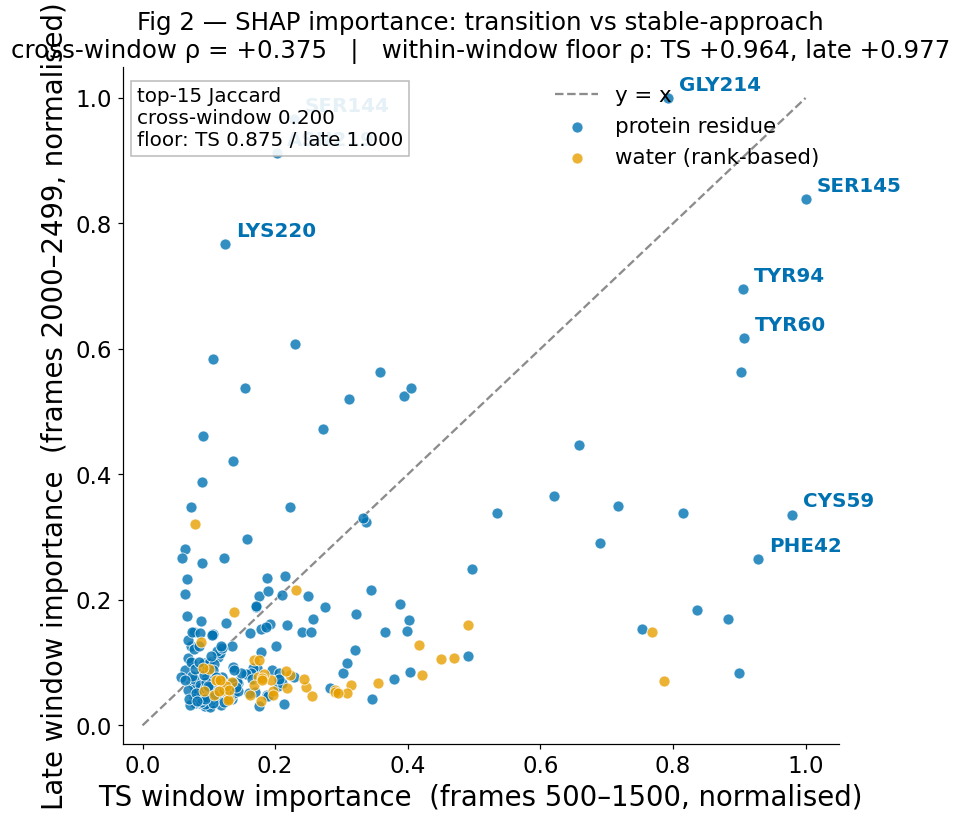

-> /mnt/data1/student/trypsin/yucheng/07.12/v4/figures/fig2_cross_window_scatter.png

TS 特有(TS 前 15 且 late 排名 > 50):
   GLY146           TS #7   late #125
   LYS87            TS #8   late #57
   ILE64            TS #9   late #53
   water rank41     TS #12  late #154
   water rank28     TS #13  late #73
   GLY63            TS #14  late #66
late 特有(late 前 15 且 TS 排名 > 50):
   SER144           late #2   TS #64
   ASN219           late #3   TS #77
   LYS220           late #5   TS #140
   LYS143           late #8   TS #62
   ALA169           late #9   TS #179
   SER168           late #13  TS #113


In [7]:
def norm(v):
    v = np.clip(v, 0, None)           # permutation 可能为负,负=不重要
    return v / (v.max() + 1e-15)

xa, xb = WINDOWS["TS"]; la, lb = WINDOWS["late"]
vx, vy = norm(fi_mean["TS"][PRIMARY]), norm(fi_mean["late"][PRIMARY])
rho_cross = spearmanr(fi_mean["TS"][PRIMARY], fi_mean["late"][PRIMARY]).statistic
fl_ts, fl_la = floor[(PRIMARY, "TS")][1], floor[(PRIMARY, "late")][1]
jac_cross = topk_jaccard(fi_mean["TS"][PRIMARY], fi_mean["late"][PRIMARY])

fig, ax = plt.subplots(figsize=(8.4, 8))
ax.plot([0, 1], [0, 1], "--", color="0.55", lw=1.5, zorder=1, label="y = x")
for msk, c, lab in [(IS_PROT, C_PROT, "protein residue"), (IS_WAT, C_WATER, "water (rank-based)")]:
    ax.scatter(vx[msk], vy[msk], s=52, c=c, alpha=0.8, edgecolor="white", lw=0.6,
               label=lab, zorder=3)

# 标注:两个窗口各自的 top-5,合并去重
lab_idx = sorted(set(np.argsort(vx)[::-1][:5].tolist()) | set(np.argsort(vy)[::-1][:5].tolist()))
for i in lab_idx:
    ax.annotate(names["name"][i], (vx[i], vy[i]), fontsize=13,
                xytext=(7, 5), textcoords="offset points",
                color=C_PROT if IS_PROT[i] else C_WATER, fontweight="bold")

ax.set_xlabel(f"TS window importance  (frames {xa}–{xb-1}, normalised)")
ax.set_ylabel(f"Late window importance  (frames {la}–{lb-1}, normalised)")
ax.set_title(f"Fig 2 — {LBL[PRIMARY]} importance: transition vs stable-approach\n"
             f"cross-window ρ = {rho_cross:+.3f}   |   within-window floor ρ: "
             f"TS {floor[(PRIMARY,'TS')][0]:+.3f}, late {floor[(PRIMARY,'late')][0]:+.3f}",
             fontsize=16)
ax.legend(loc="upper right", frameon=False); ax.set_xlim(-0.03, 1.05); ax.set_ylim(-0.03, 1.05)
ax.text(0.02, 0.97, f"top-{TOP_K} Jaccard\ncross-window {jac_cross:.3f}\n"
                    f"floor: TS {fl_ts:.3f} / late {fl_la:.3f}",
        transform=ax.transAxes, va="top", fontsize=13,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
p = os.path.join(FIG_DIR, "fig2_cross_window_scatter.png"); fig.savefig(p); plt.show()
print("->", p)

print(f"\nTS 特有(TS 前 15 且 late 排名 > 50):")
rk_x, rk_y = len(vx) - 1 - np.argsort(np.argsort(vx)), len(vy) - 1 - np.argsort(np.argsort(vy))
for i in np.argsort(vx)[::-1][:TOP_K]:
    if rk_y[i] > 50: print(f"   {names['name'][i]:<16s} TS #{rk_x[i]+1:<3d} late #{rk_y[i]+1}")
print(f"late 特有(late 前 15 且 TS 排名 > 50):")
for i in np.argsort(vy)[::-1][:TOP_K]:
    if rk_x[i] > 50: print(f"   {names['name'][i]:<16s} late #{rk_y[i]+1:<3d} TS #{rk_x[i]+1}")

## Part 6 — Fig 3:沿序列的 per-residue profile + 水面板(guide §4)

- 上 panel = TS,下 panel = late,**共享 y 轴**(guide §6:比较才是重点)
- 50 个水放**单独的小 panel**(x = rank 0–49),它们没有序列位置
- 按 **IN→OUT 方向着色**:红 = OUT 时配体更远,蓝 = OUT 时更近

方向着色是 Edina 15:15 那张图加的,guide 正文里没有。重要性只说"这个坐标要紧",
方向说"要紧在哪一边",信息量大得多。方向 = 该窗口内 OUT 组均值减 IN 组均值的符号
(标准化后的效应量),**只是描述性标注,不参与建模,也不参与特征选择**。

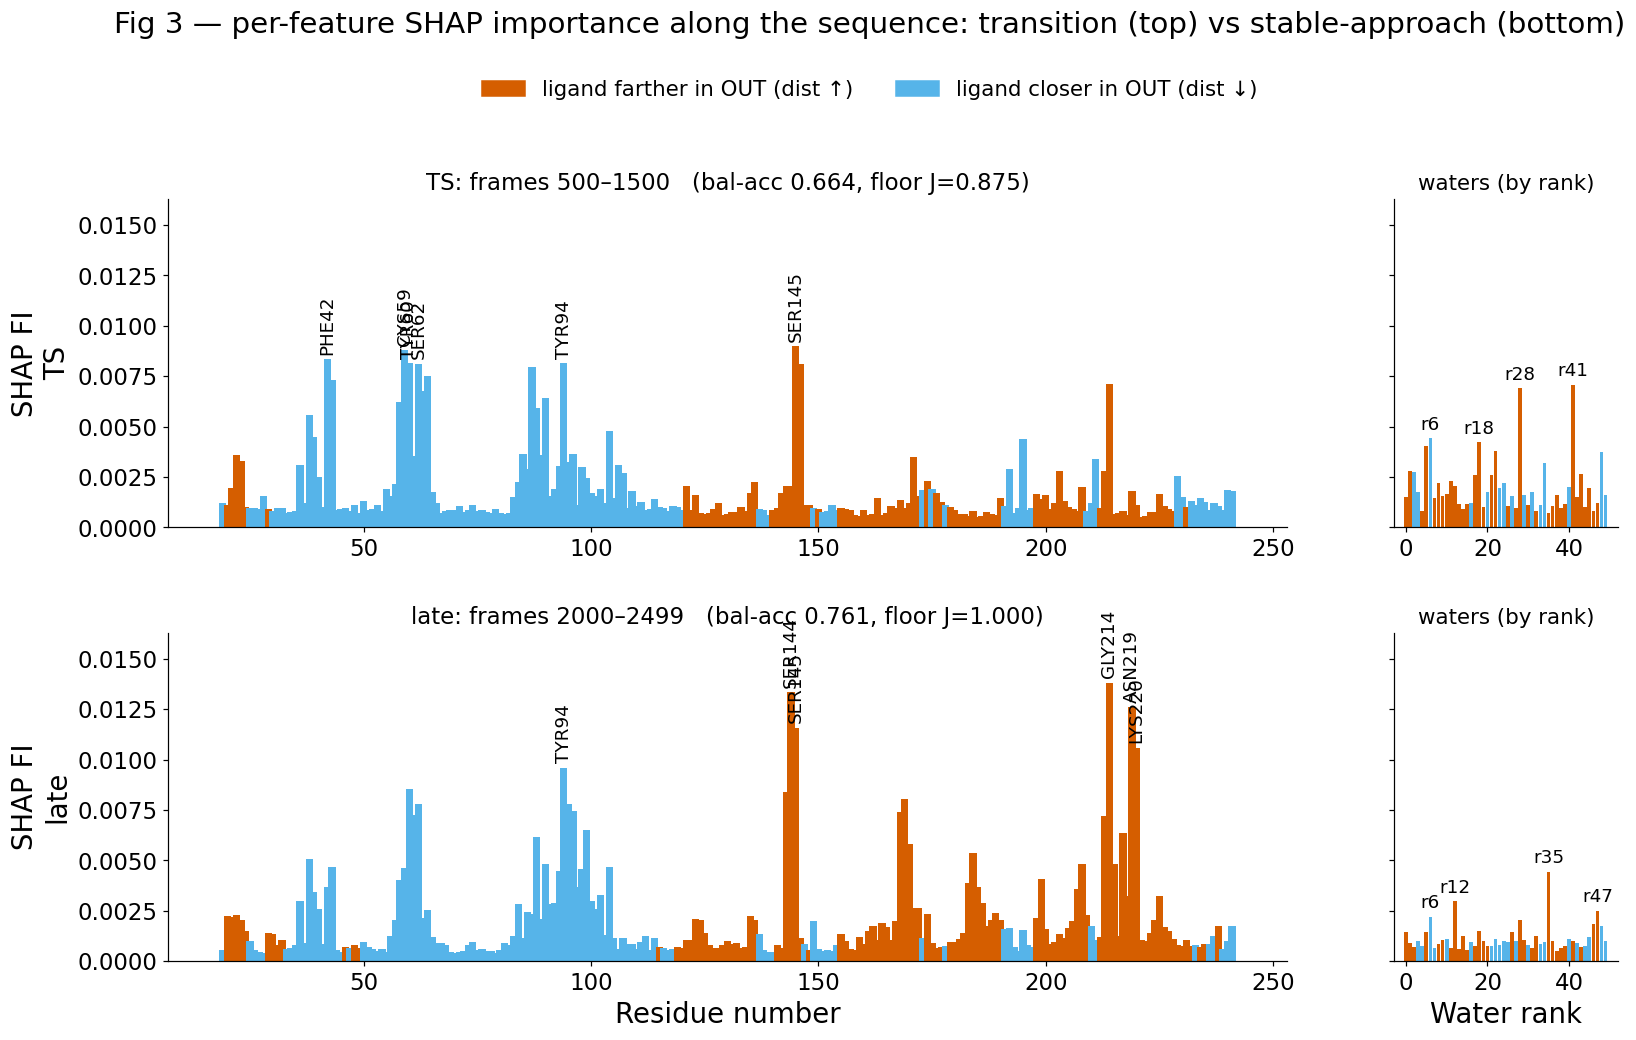

-> /mnt/data1/student/trypsin/yucheng/07.12/v4/figures/fig3_profile.png

CAPTION: Per-feature SHAP importance, RandomForest on trajectory-level window means, 5-fold grouped CV averaged over 10 seeds, computed on held-out rows. Top: TS window (frames 500–1500); bottom: stable-approach (frames 2000–2499); shared y-axis. Bars coloured by the IN→OUT direction of the ligand–feature distance. Right panels: the 50 water CVs, which have no sequence position — these are RANK-BASED, i.e. the i-th closest water is a different molecule in each frame, so they are labelled by rank and not by a fixed HOH id.


In [8]:
def direction_sign(X, y):
    a, b = X[y == 1], X[y == 0]                       # OUT, IN
    pooled = np.sqrt((a.var(axis=0, ddof=1) + b.var(axis=0, ddof=1)) / 2.0)
    return np.sign((a.mean(axis=0) - b.mean(axis=0)) / (pooled + 1e-12))

DIRS = {w: direction_sign(Xs[w], y) for w in WINDOWS}
V = {w: np.nan_to_num(np.clip(fi_mean[w][PRIMARY], 0, None), nan=0.0) for w in WINDOWS}
ymax = max(V[w].max() for w in WINDOWS) * 1.18        # guide §6:两 panel 同 y 轴
assert np.isfinite(ymax) and ymax > 0, f"ymax={ymax} 无效 —— {PRIMARY} 的数据有问题"

fig = plt.figure(figsize=(17, 9))
gs = GridSpec(2, 2, width_ratios=[5, 1], hspace=0.32, wspace=0.16)

for row, w in enumerate(WINDOWS):
    a, b = WINDOWS[w]
    unreliable = floor[(PRIMARY, w)][1] < 0.10

    axp = fig.add_subplot(gs[row, 0])
    vp, dp = V[w][IS_SEQ], DIRS[w][IS_SEQ]
    axp.bar(XAXIS, vp, width=1.6, color=np.where(dp >= 0, C_FAR, C_NEAR))
    for i in np.argsort(vp)[::-1][:6]:                # 标注前 6
        axp.annotate(names["name"][IS_SEQ][i], (XAXIS[i], vp[i]), rotation=90,
                     fontsize=12, ha="center", va="bottom", xytext=(0, 3),
                     textcoords="offset points")
    axp.set_ylim(0, ymax); axp.set_ylabel(f"{LBL[PRIMARY]} FI\n{w}")
    axp.set_title(f"{w}: frames {a}–{b-1}   (bal-acc {np.mean(oof[w]):.3f}, "
                  f"floor J={floor[(PRIMARY,w)][1]:.3f})"
                  + ("   ⚠ NOT REPRODUCIBLE" if unreliable else ""),
                  fontsize=15, color="#B00" if unreliable else "black")
    if row == len(WINDOWS) - 1: axp.set_xlabel(XLABEL)

    axw = fig.add_subplot(gs[row, 1])
    vw, dw = V[w][IS_WAT], DIRS[w][IS_WAT]
    axw.bar(np.arange(N_WATERS), vw, width=0.9, color=np.where(dw >= 0, C_FAR, C_NEAR))
    for i in np.argsort(vw)[::-1][:4]:
        axw.annotate(f"r{i}", (i, vw[i]), fontsize=12, ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")
    axw.set_ylim(0, ymax); axw.set_yticklabels([]); axw.set_title("waters (by rank)", fontsize=14)
    if row == len(WINDOWS) - 1: axw.set_xlabel("Water rank")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=C_FAR, label="ligand farther in OUT (dist ↑)"),
                    Patch(color=C_NEAR, label="ligand closer in OUT (dist ↓)")],
           loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"Fig 3 — per-feature {LBL[PRIMARY]} importance along the sequence: "
             f"transition (top) vs stable-approach (bottom)", y=1.07)
p = os.path.join(FIG_DIR, "fig3_profile.png"); fig.savefig(p); plt.show()
print("->", p)
print(f"\nCAPTION: Per-feature {LBL[PRIMARY]} importance, RandomForest on trajectory-level window "
      f"means, {N_SPLITS}-fold grouped CV averaged over {len(SEEDS)} seeds, computed on held-out rows. "
      f"Top: TS window (frames {WINDOWS['TS'][0]}–{WINDOWS['TS'][1]-1}); bottom: stable-approach "
      f"(frames {WINDOWS['late'][0]}–{WINDOWS['late'][1]-1}); shared y-axis. Bars coloured by the "
      "IN→OUT direction of the ligand–feature distance. Right panels: the 50 water CVs, which have "
      "no sequence position — these are RANK-BASED, i.e. the i-th closest water is a different "
      "molecule in each frame, so they are labelled by rank and not by a fixed HOH id.")

## Part 7 — Fig 4:PyMOL 结构图(guide §5)

两步:

1. **把 per-residue 重要性归一化到 0–100 写进 B-factor 列**,每个窗口一个 PDB
2. **生成 `render_fi.pml`**,两个窗口用**同一色标、同一取向**渲染

guide §5 的要点:
- cartoon putty 厚度 + blue→white→red 双重编码(故意冗余,印刷时读得清)
- BEN 用 sticks 显示 —— 每个 CV 都是到 BEN 的距离,它是参照点
- **水不进结构图**:CV 是按 rank 定义的(每帧不同分子),没法放成固定原子。
  水的重要性在 Fig 3 的右侧面板里报

这一格只写文件,不需要装 PyMOL。生成后在有 PyMOL 的机器上跑 `pymol -cq render_fi.pml`。

In [9]:
# ============ B-factor:百分位映射(线性映射会让整个蛋白都是蓝的)============
from scipy.stats import rankdata

prot_vals = {w: np.clip(np.nan_to_num(fi_mean[w][PRIMARY][:N_PROTEIN]), 0, None)
             for w in WINDOWS}
pooled = np.concatenate([prot_vals[w] for w in WINDOWS])
pct = rankdata(pooled) / len(pooled) * 99.0
scaled = {w: pct[i * N_PROTEIN:(i + 1) * N_PROTEIN] for i, w in enumerate(WINDOWS)}
B_MAX = 99.0

def write_fi_pdb(fi_prot, out_pdb):
    t = md.load(PDB_PATH)
    prot = [r for r in t.topology.residues if r.is_protein]
    b = np.zeros(t.n_atoms)
    for i, r in enumerate(prot):
        for atom in r.atoms:
            b[atom.index] = fi_prot[i]
    t.save_pdb(out_pdb, bfactors=b)
    return out_pdb

pdbs, tops = {}, {}
for w in WINDOWS:
    pdbs[w] = write_fi_pdb(scaled[w], os.path.join(FIG_DIR, f"fi_{w}.pdb"))
    tops[w] = np.argsort(prot_vals[w])[::-1][:5]

# ============ PyMOL 脚本 ============
first = list(WINDOWS)[0]
lines = [
    "# guide §5 —— 两窗口同色标同取向。B-factor = 合并分布上的百分位。",
    "set auto_zoom, off",
    "bg_color white", "set ray_opaque_background, 1", "set ray_shadows, 0",
    "set antialias, 2",
    "set cartoon_putty_scale_max, 3.5", "set cartoon_putty_scale_min, 0.5",
    "set stick_radius, 0.30",
    "set label_size, 24", "set label_color, black",
    "set label_outline_color, white", "set float_labels, on",
    "set label_position, (0, 0, 10)", "set sphere_scale, 0.55",
    "",
]

for w in WINDOWS:
    sel = f"prot_{w}"
    resis = "+".join(str(names["resid"][i]) for i in tops[w])
    lab2 = "+".join(str(names["resid"][i]) for i in tops[w][:2])
    lines += [
        f"load {pdbs[w]}, {sel}", f"hide everything, {sel}",
        f"show cartoon, {sel}", f"cartoon putty, {sel}",
        f"spectrum b, blue_white_red, {sel}, minimum=0, maximum={B_MAX:.0f}",
        f"show sticks, {sel} and resn BEN", f"color yellow, {sel} and resn BEN",
        f"show spheres, {sel} and resi {resis} and name CA",
        f"color green, {sel} and resi {resis} and name CA",
        f"select lab_{w}, {sel} and resi {lab2} and name CA",
        f'label lab_{w}, "%s%s" % (resn, resi)', "deselect",
    ]

lines += [f"orient prot_{first}", f"zoom prot_{first}, buffer=0, complete=1", ""]

for w in WINDOWS:
    lines += ["disable *", f"enable prot_{w}", f"enable lab_{w}",
              "ray 1400, 1700", f"png {FIG_DIR}/fig4_{w}.png, dpi=300", ""]
lines += ["turn y, 180", ""]
for w in WINDOWS:
    lines += ["disable *", f"enable prot_{w}", f"enable lab_{w}",
              "ray 1400, 1700", f"png {FIG_DIR}/fig4_{w}_back.png, dpi=300", ""]

pml = os.path.join(FIG_DIR, "render_fi.pml")
open(pml, "w").write("\n".join(lines))
print("->", pml)
print("   pymol -cq", pml)
for w in WINDOWS:
    print(f"   {w:5s} top-5(绿球): " + ", ".join(names["name"][i] for i in tops[w]))

-> /mnt/data1/student/trypsin/yucheng/07.12/v4/figures/render_fi.pml
   pymol -cq /mnt/data1/student/trypsin/yucheng/07.12/v4/figures/render_fi.pml
   TS    top-5(绿球): SER145, CYS59, PHE42, TYR60, TYR94
   late  top-5(绿球): GLY214, SER144, ASN219, SER145, LYS220


## Part 8 — 解读文本(guide §7 第 5 项)

自动带上真实数字。**诚实标注哪一侧的结论撑得住、哪一侧撑不住** —— 地板低于 0.10 的
窗口,它的 top 特征是噪声,不能当发现报。

In [10]:
lines = []
lines.append("=" * 78)
lines.append("DELIVERABLE — interpretation (guide §7, item 5)")
lines.append("=" * 78)
lines.append(RATIONALE)
lines.append("")

for w in WINDOWS:
    a, b = WINDOWS[w]
    j = floor[(PRIMARY, w)][1]
    top = np.argsort(np.clip(fi_mean[w][PRIMARY], 0, None))[::-1][:10]
    n_wat = int(IS_WAT[top].sum())
    lines.append(f"[{w}] frames {a}-{b-1} ({b-a} frames), balanced accuracy "
                 f"{np.mean(oof[w]):.3f} +/- {np.std(oof[w]):.3f}")
    lines.append(f"   top-10 ({LBL[PRIMARY]}): " + ", ".join(names["name"][i] for i in top))
    lines.append(f"   composition: {10-n_wat} protein residues, {n_wat} waters")
    lines.append(f"   reproducibility floor (split-half top-{TOP_K} Jaccard) = {j:.3f}"
                 + ("   *** BELOW 0.10 — these features are NOT reproducible across seeds "
                    "and must NOT be reported as a finding ***" if j < 0.10 else "   (usable)"))
    lines.append("")

# ---- 两种方法的 TS top-10 并列(特征身份是方法依赖的)----
lines.append("TS top-10 under BOTH methods (feature identity is method-dependent):")
for m in ("perm", "shap"):
    if m in METHODS:
        top = np.argsort(np.clip(fi_mean["TS"][m], 0, None))[::-1][:10]
        lines.append(f"   {m:<5}: " + ", ".join(names["name"][i] for i in top))
lines.append("   permutation is unbiased but spiky (it concentrates on a few of a redundant "
             "group); SHAP is precise but same-source as Gini and spreads credit smoothly. "
             "Both enrich waters at the TS; they differ on WHICH waters rank top.")
lines.append("")

# ---- 水的 regime 转移(最强的一条结论,跨方法稳健)----
from scipy.stats import fisher_exact, hypergeom
TOP_N = 50
lines.append(f"WATER REGIME SHIFT (top-{TOP_N} composition, {N_WATERS}/{len(names['name'])} "
             f"= {N_WATERS/len(names['name']):.1%} baseline):")
water_rows = {}
for m in METHODS:
    cnt = {w: int(IS_WAT[np.argsort(fi_mean[w][m])[::-1][:TOP_N]].sum()) for w in WINDOWS}
    odds, p = fisher_exact([[cnt["TS"], TOP_N - cnt["TS"]],
                            [cnt["late"], TOP_N - cnt["late"]]])
    water_rows[m] = (cnt, odds, p)
    lines.append(f"   {m:<5}: TS {cnt['TS']:>2}/{TOP_N}  vs  late {cnt['late']:>2}/{TOP_N}"
                 f"   OR={odds:.2f}  Fisher p={p:.2e}")
lines.append("   -> waters are involved at the transition and drop out as the system settles; "
             "consistent across the reproducible methods. This is the desolvation signal.")
lines.append("")

# ---- 衰减校正后的跨窗口相关(guide §8 那个 rho=0.05 的修正)----
fr_ts, fr_la = floor[(PRIMARY, "TS")][0], floor[(PRIMARY, "late")][0]
if min(fr_ts, fr_la) >= MIN_RELIABILITY:
    dis = rho_cross / np.sqrt(fr_ts * fr_la)
    lines.append(f"DISATTENUATED cross-window correlation ({PRIMARY}): "
                 f"rho_obs {rho_cross:+.3f} / sqrt({fr_ts:.3f} x {fr_la:.3f}) = {dis:+.3f}")
    lines.append(f"   Reliability is high ({fr_ts:.3f}/{fr_la:.3f}), so the noise correction barely "
                 f"changes the estimate: the true cross-window correlation is ~{dis:.2f}, i.e. "
                 "PARTIAL OVERLAP, not independence.")
    lines.append(f"   The near-zero value reported with permutation importance (guide §8, rho=0.05; "
                 f"this dataset: {spearmanr(fi_mean['TS']['perm'], fi_mean['late']['perm']).statistic:+.3f}) "
                 f"is consistent with that method's own reproducibility floor "
                 f"(within-window rho = {floor[('perm','TS')][0]:.3f}/{floor[('perm','late')][0]:.3f}) "
                 "and should NOT be read as evidence of independence.")
    lines.append("")

# ---- 方法学发现:permutation 为什么在 late 失效 ----
lines.append("METHOD NOTE — why permutation fails in the late window:")
for w in WINDOWS:
    zf = float((np.abs(per_seed[w]["perm"]) < 1e-12).mean())
    lines.append(f"   {w:<5}: {zf:.1%} of permutation importances are exactly zero; "
                 f"split-half floor J = {floor[('perm', w)][1]:.3f}")
lines.append("   Redundant coordinates mask each other: permuting one leaves its correlated "
             "partners intact, so accuracy does not drop and the importance collapses to zero. "
             "Permutation is unbiased but imprecise here; SHAP is precise but same-source as Gini. "
             "Feature identity is therefore method-dependent (permutation is spiky, SHAP is smooth), "
             "while the water regime shift above is robust to that choice.")
lines.append("")

lines.append(f"Cross-window: Spearman rho = {rho_cross:+.3f}, top-{TOP_K} Jaccard = {jac_cross:.3f}.")
lines.append(f"   Reference floors (same window, different seeds): "
             f"TS J={fl_ts:.3f}, late J={fl_la:.3f}.")
if min(fl_ts, fl_la) < 0.10:
    weak = "late" if fl_la < fl_ts else "TS"
    lines.append(f"   INTERPRETATION LIMIT: the {weak} window's importances are at the noise "
                 f"floor, so a low cross-window overlap CANNOT be read as 'the two regimes use "
                 f"different coordinates' — one side simply is not measurable. Report the "
                 f"reproducible window's signature only, and state this limit explicitly.")
else:
    lines.append("   Cross-window overlap is below both within-window floors -> the important "
             "feature set PARTIALLY changes between the two regimes (see disattenuated rho above). "
             "Report this as partial overlap with substantial regime-specific components, "
             "not as independence.")
lines.append("")
lines.append("Framing (Edina, 7/27 15:27): early and late importances are not expected to be the "
             "same; the difference itself demonstrates that the early window captures TS "
             "information. Report which residues/waters are the EARLY determinants of commitment, "
             "and how that set changes as the system settles.")
lines.append("")
lines.append("Caveats to carry in every caption: (i) water CVs are rank-based - the i-th closest "
             "water is a different molecule each frame; (ii) the two windows differ in length "
             f"({WINDOWS['TS'][1]-WINDOWS['TS'][0]} vs {WINDOWS['late'][1]-WINDOWS['late'][0]} "
             "frames), so compare ranks, not raw importance magnitudes; (iii) higher late-window "
             "accuracy is expected - the outcome is declaring itself - and is not evidence that "
             "the late window is more informative about the transition.")
lines.append("(iv) the 4/6 overlap with the reference demo's top TS waters is a SAME-METHOD "
             "reproduction (that demo also used permutation importance), so it confirms that "
             "permutation is reproducible in the TS window but does not adjudicate between "
             "permutation and SHAP.")
txt = "\n".join(lines)
print(txt)
open(os.path.join(FIG_DIR, "interpretation.txt"), "w").write(txt)
json.dump({"primary_method": PRIMARY,
           "floors": {f"{m}|{w}": floor[(m, w)] for m in METHODS for w in WINDOWS},
           "cross_window": {"rho": float(rho_cross), "jaccard": float(jac_cross)},
           "oof": {w: float(np.mean(oof[w])) for w in WINDOWS},
           "windows": {w: list(WINDOWS[w]) for w in WINDOWS},
           "xaxis_clean_resid": bool(CLEAN_RESID)},
          open(os.path.join(FIG_DIR, "figure_summary.json"), "w"), indent=2)
print(f"\n-> {FIG_DIR}/interpretation.txt  +  figure_summary.json")
print(f"-> 四张图 + PDB + pml 都在 {FIG_DIR}")

DELIVERABLE — interpretation (guide §7, item 5)
Primary method: shap. Chosen on measured reproducibility rather than by default: perm floor (split-half top-15 Jaccard) = 0.200 (TS)/0.034 (late); shap floor (split-half top-15 Jaccard) = 0.875 (TS)/1.000 (late). Gini is reported in Fig 1 for completeness but never used to draw conclusions, because for tree models Gini and TreeExplainer-SHAP derive from the same splits and are not independent checks of one another (guide §8).

[TS] frames 500-1500 (1001 frames), balanced accuracy 0.664 +/- 0.011
   top-10 (SHAP): SER145, CYS59, PHE42, TYR60, TYR94, SER62, GLY146, LYS87, ILE64, CYS43
   composition: 10 protein residues, 0 waters
   reproducibility floor (split-half top-15 Jaccard) = 0.875   (usable)

[late] frames 2000-2499 (500 frames), balanced accuracy 0.761 +/- 0.017
   top-10 (SHAP): GLY214, SER144, ASN219, SER145, LYS220, TYR94, TYR60, LYS143, ALA169, SER62
   composition: 10 protein residues, 0 waters
   reproducibility floor (split

In [11]:
# 用 Gini(可复现的那个)预览跨窗口对比会是什么样
# 注意:这只是诊断,不是结论 —— guide §8 明确禁止用 Gini 下结论
g_ts, g_la = fi_mean["TS"]["gini"], fi_mean["late"]["gini"]
print(f"Gini 跨窗口:  rho = {spearmanr(g_ts, g_la).statistic:+.3f}   "
      f"top-{TOP_K} Jaccard = {topk_jaccard(g_ts, g_la):.3f}")
print(f"Gini 地板  :  TS {floor[('gini','TS')][1]:.3f}   late {floor[('gini','late')][1]:.3f}")
print("\n判据:跨窗口 Jaccard 明显低于两个地板 -> 重要特征集合确实换了")
print("      如果这里成立,SHAP 大概率会给出同样的结论,而 SHAP 是可以报的")

Gini 跨窗口:  rho = +0.398   top-15 Jaccard = 0.200
Gini 地板  :  TS 0.765   late 0.875

判据:跨窗口 Jaccard 明显低于两个地板 -> 重要特征集合确实换了
      如果这里成立,SHAP 大概率会给出同样的结论,而 SHAP 是可以报的


In [12]:
# Edina guide §8 的 TS top waters
edina = [41, 18, 2, 28, 34, 24]
print("Edina 的 6 个水在你各方法下的排名(TS 窗口,274 个特征里):")
for m in METHODS:
    v = fi_mean["TS"][m]
    rk = len(v) - 1 - np.argsort(np.argsort(v))     # 0 = 最重要
    print(f"  {m:5s}: " + ", ".join(f"r{w}=#{rk[224+w]+1}" for w in edina))

print("\n各方法 top-50 里水的占比(共 50 个水 / 274 特征,基线 18%):")
for m in METHODS:
    top50 = np.argsort(fi_mean["TS"][m])[::-1][:50]
    print(f"  {m:5s}: TS {IS_WAT[top50].sum()}/50   ", end="")
    t2 = np.argsort(fi_mean["late"][m])[::-1][:50]
    print(f"late {IS_WAT[t2].sum()}/50")

Edina 的 6 个水在你各方法下的排名(TS 窗口,274 个特征里):
  gini : r41=#14, r18=#21, r2=#33, r28=#12, r34=#38, r24=#66
  perm : r41=#2, r18=#106, r2=#4, r28=#1, r34=#183, r24=#7
  shap : r41=#12, r18=#23, r2=#46, r28=#13, r34=#36, r24=#59

各方法 top-50 里水的占比(共 50 个水 / 274 特征,基线 18%):
  gini : TS 11/50   late 1/50
  perm : TS 14/50   late 7/50
  shap : TS 13/50   late 2/50
